# 02. Exploratory Data Analysis

Explore feature distributions, anomalous transaction behavior, and correlations with fraud labels.

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
DATA_PATH = "../data/raw/creditcard.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)

Dataset shape: (284807, 31)


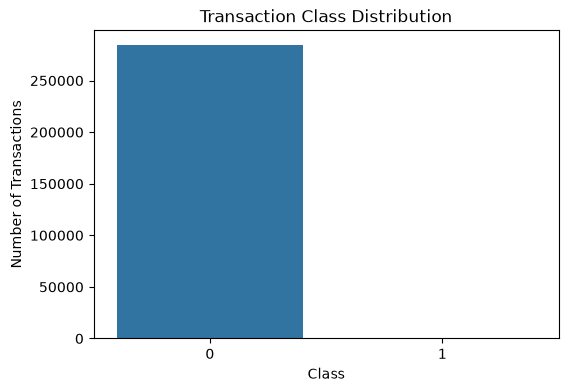

In [27]:
class_counts = df["Class"].value_counts()

plt.figure(figsize=(6, 4))

sns.barplot(
    x=class_counts.index,
    y=class_counts.values
)

plt.title("Transaction Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Transactions")

plt.show()

In [28]:
class_distribution = (
    df["Class"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("percentage")
)

class_distribution

Class
0    99.827251
1     0.172749
Name: percentage, dtype: float64

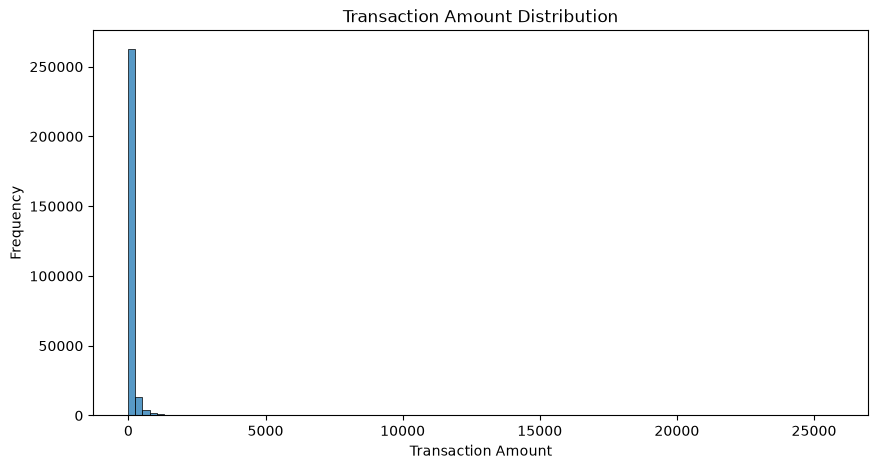

In [29]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="Amount",
    bins=100
)

plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

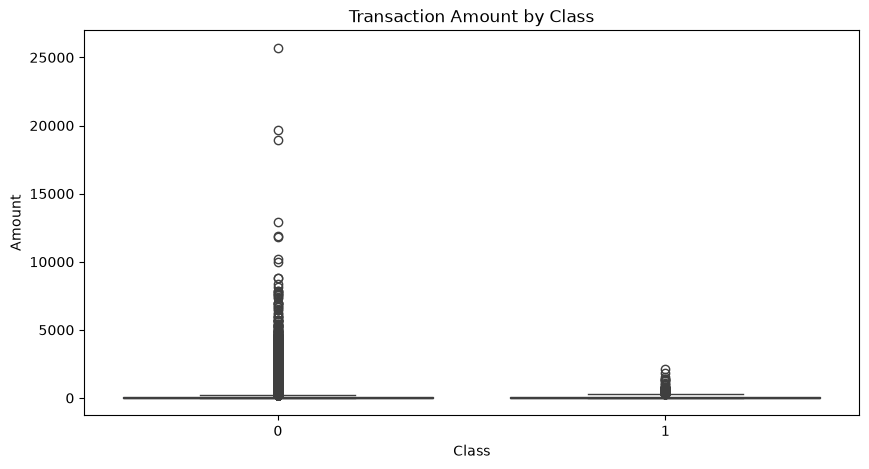

In [30]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x="Class",
    y="Amount"
)

plt.title("Transaction Amount by Class")
plt.xlabel("Class")
plt.ylabel("Amount")

plt.show()

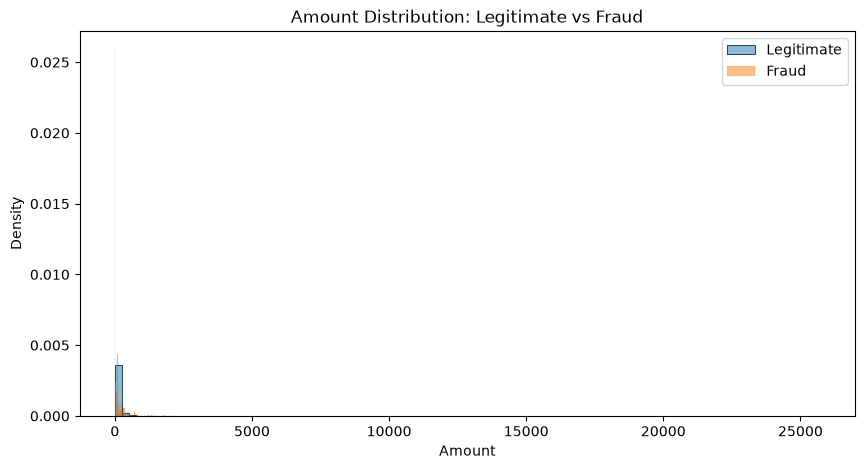

In [31]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df[df["Class"] == 0],
    x="Amount",
    bins=100,
    stat="density",
    alpha=0.5,
    label="Legitimate"
)

sns.histplot(
    data=df[df["Class"] == 1],
    x="Amount",
    bins=100,
    stat="density",
    alpha=0.5,
    label="Fraud"
)

plt.title("Amount Distribution: Legitimate vs Fraud")
plt.xlabel("Amount")
plt.ylabel("Density")
plt.legend()

plt.show()

In [32]:
amount_by_class = df.groupby("Class")["Amount"].describe()

amount_by_class

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


In [33]:
amount_summary = df.groupby("Class")["Amount"].agg(
    ["mean", "median", "std", "min", "max"]
)

amount_summary

,mean,median,std,min,max
Class,,,,,
0,88.291022,22.00,250.105092,0.0,25691.16
1,122.211321,9.25,256.683288,0.0,2125.87


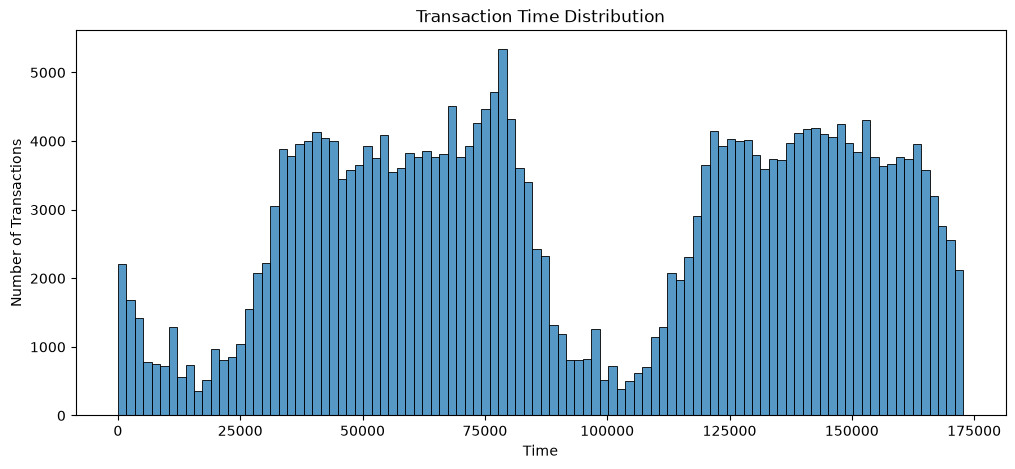

In [34]:
plt.figure(figsize=(12, 5))

sns.histplot(
    data=df,
    x="Time",
    bins=100
)

plt.title("Transaction Time Distribution")
plt.xlabel("Time")
plt.ylabel("Number of Transactions")

plt.show()

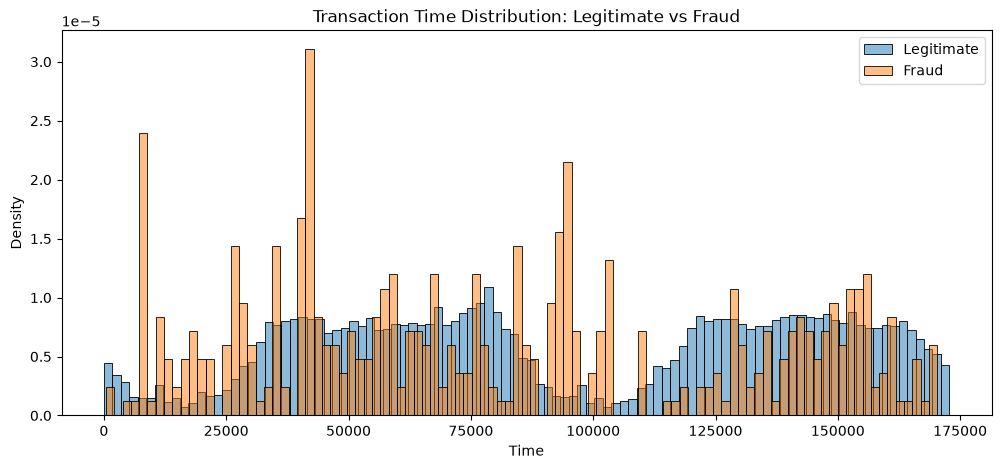

In [35]:
plt.figure(figsize=(12, 5))

sns.histplot(
    data=df[df["Class"] == 0],
    x="Time",
    bins=100,
    stat="density",
    alpha=0.5,
    label="Legitimate"
)

sns.histplot(
    data=df[df["Class"] == 1],
    x="Time",
    bins=100,
    stat="density",
    alpha=0.5,
    label="Fraud"
)

plt.title("Transaction Time Distribution: Legitimate vs Fraud")
plt.xlabel("Time")
plt.ylabel("Density")
plt.legend()

plt.show()

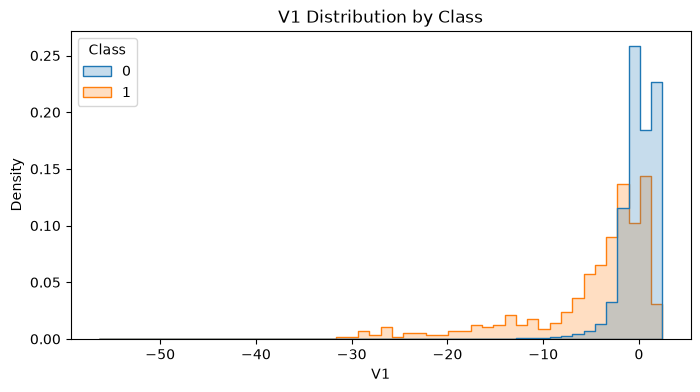

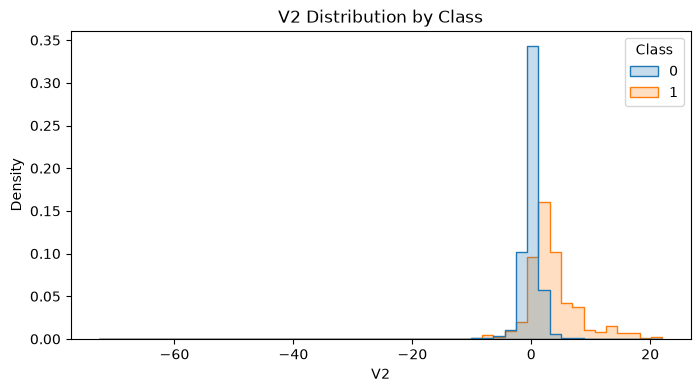

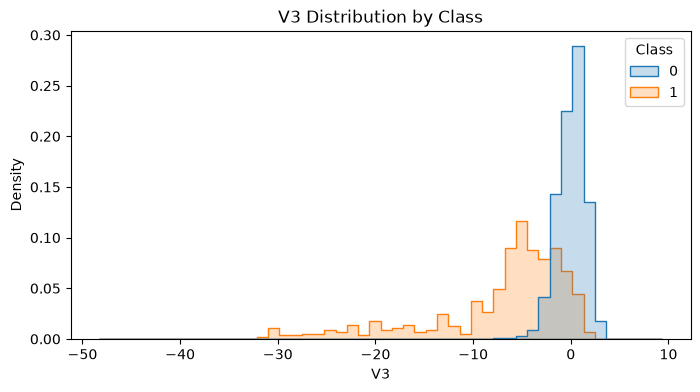

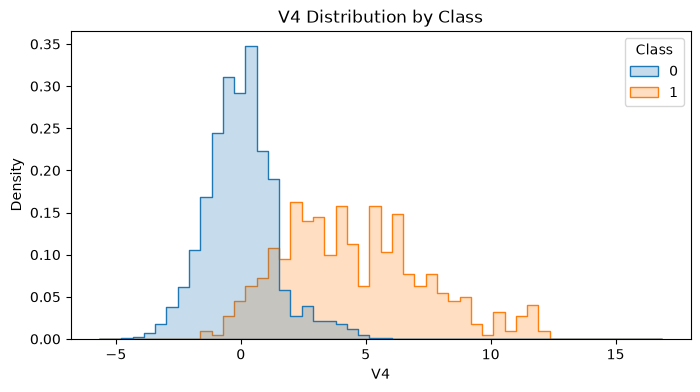

In [36]:
features_to_plot = ["V1", "V2", "V3", "V4"]

for feature in features_to_plot:

    plt.figure(figsize=(8, 4))

    sns.histplot(
        data=df,
        x=feature,
        hue="Class",
        bins=50,
        stat="density",
        common_norm=False,
        element="step"
    )

    plt.title(f"{feature} Distribution by Class")
    plt.show()

In [37]:
feature_columns = [
    column for column in df.columns
    if column not in ["Time", "Amount", "Class"]
]

class_means = df.groupby("Class")[feature_columns].mean().T

class_means

Class,0,1
V1,0.008258,-4.771948
V2,-0.006271,3.623778
V3,0.012171,-7.033281
V4,-0.007860,4.542029
V5,0.005453,-3.151225
V6,0.002419,-1.397737
V7,0.009637,-5.568731
V8,-0.000987,0.570636
V9,0.004467,-2.581123
V10,0.009824,-5.676883


In [38]:
mean_difference = (
    df[df["Class"] == 1][feature_columns].mean()
    -
    df[df["Class"] == 0][feature_columns].mean()
)

mean_difference.sort_values()

V3    -7.045452
V14   -6.983787
V17   -6.677371
V12   -6.270225
V10   -5.686707
V7    -5.578368
V1    -4.780206
V16   -4.147110
V5    -3.156678
V9    -2.585589
V18   -2.250195
V6    -1.400155
V13   -0.109523
V24   -0.105312
V15   -0.093090
V23   -0.040378
V22    0.014073
V25    0.041521
V26    0.051738
V28    0.075798
V27    0.170870
V20    0.372964
V8     0.571623
V19    0.681837
V21    0.714823
V2     3.630049
V11    3.806749
V4     4.549889
dtype: float64

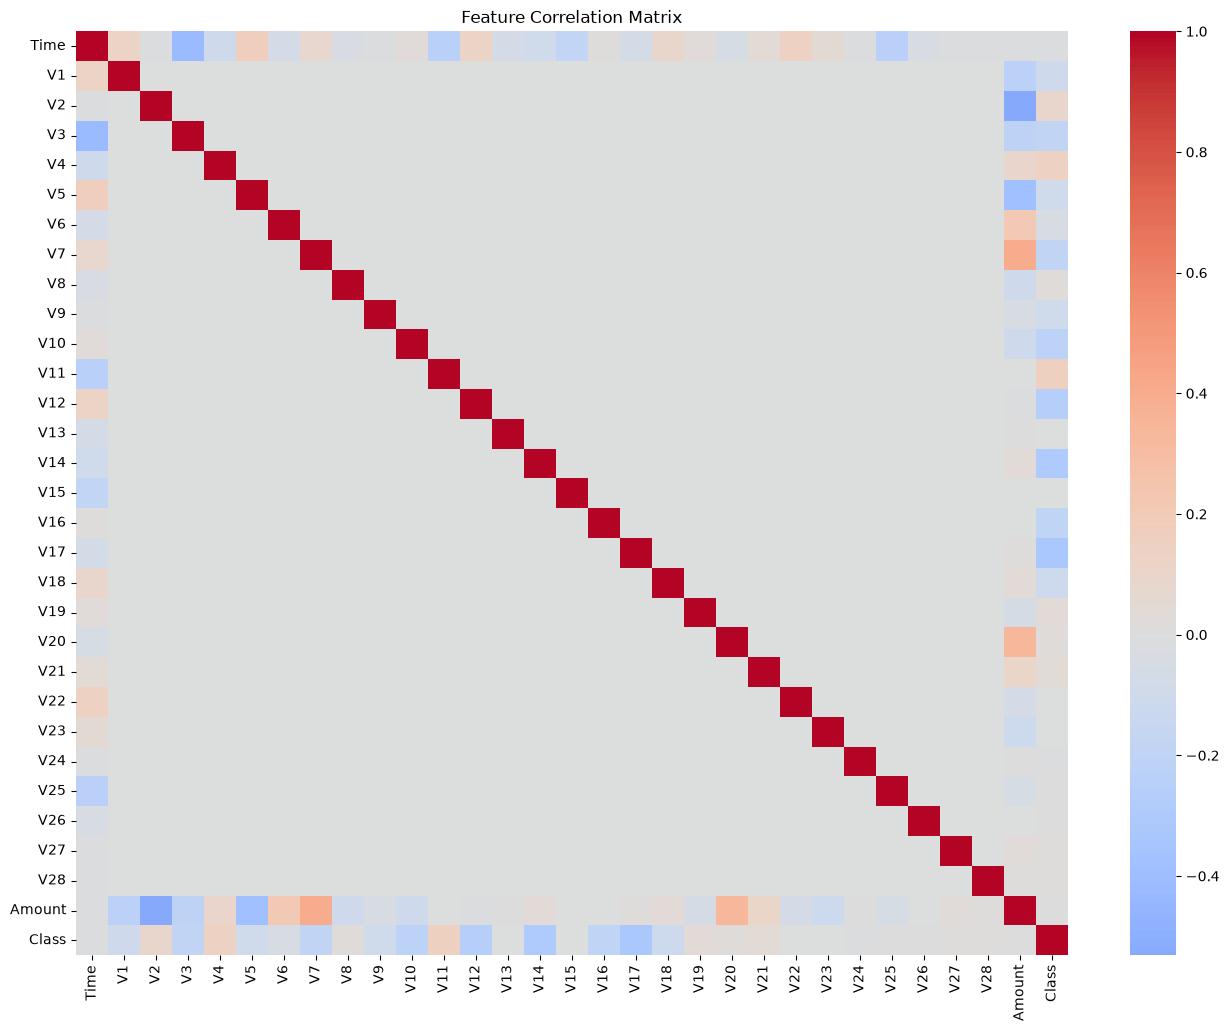

In [39]:
correlation_matrix = df.corr()

plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Matrix")
plt.show()

In [40]:
target_correlation = (
    df.corr()["Class"]
    .drop("Class")
    .sort_values()
)

target_correlation

V17      -0.326481
V14      -0.302544
V12      -0.260593
V10      -0.216883
V16      -0.196539
V3       -0.192961
V7       -0.187257
V18      -0.111485
V1       -0.101347
V9       -0.097733
V5       -0.094974
V6       -0.043643
Time     -0.012323
V24      -0.007221
V13      -0.004570
V15      -0.004223
V23      -0.002685
V22       0.000805
V25       0.003308
V26       0.004455
Amount    0.005632
V28       0.009536
V27       0.017580
V8        0.019875
V20       0.020090
V19       0.034783
V21       0.040413
V2        0.091289
V4        0.133447
V11       0.154876
Name: Class, dtype: float64

In [41]:
fraud_df = df[df["Class"] == 1]

print("Fraud transactions:", len(fraud_df))

fraud_df.head()



Fraud transactions: 492


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
541,406.0,-2.312227,1.951992,-1.609851,3.997906,-0.522188,-1.426545,-2.537387,1.391657,-2.770089,...,0.517232,-0.035049,-0.465211,0.320198,0.044519,0.177840,0.261145,-0.143276,0.00,1
623,472.0,-3.043541,-3.157307,1.088463,2.288644,1.359805,-1.064823,0.325574,-0.067794,-0.270953,...,0.661696,0.435477,1.375966,-0.293803,0.279798,-0.145362,-0.252773,0.035764,529.00,1
4920,4462.0,-2.303350,1.759247,-0.359745,2.330243,-0.821628,-0.075788,0.562320,-0.399147,-0.238253,...,-0.294166,-0.932391,0.172726,-0.087330,-0.156114,-0.542628,0.039566,-0.153029,239.93,1
6108,6986.0,-4.397974,1.358367,-2.592844,2.679787,-1.128131,-1.706536,-3.496197,-0.248778,-0.247768,...,0.573574,0.176968,-0.436207,-0.053502,0.252405,-0.657488,-0.827136,0.849573,59.00,1
6329,7519.0,1.234235,3.019740,-4.304597,4.732795,3.624201,-1.357746,1.713445,-0.496358,-1.282858,...,-0.379068,-0.704181,-0.656805,-1.632653,1.488901,0.566797,-0.010016,0.146793,1.00,1


In [42]:
fraud_df["Amount"].describe()
df[df["Class"] == 0]["Amount"].describe()

count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

In [43]:
fraud_df["Time"].describe()
legitimate_df = df[df["Class"] == 0]

legitimate_df["Time"].describe()

count    284315.000000
mean      94838.202258
std       47484.015786
min           0.000000
25%       54230.000000
50%       84711.000000
75%      139333.000000
max      172792.000000
Name: Time, dtype: float64

In [44]:
df.nlargest(10, "Amount")[["Time", "Amount", "Class"]]

,Time,Amount,Class
274771,166198.0,25691.16,0
58465,48401.0,19656.53,0
151296,95286.0,18910.00,0
46841,42951.0,12910.93,0
54018,46253.0,11898.09,0
169457,119713.0,11789.84,0
284249,172273.0,10199.44,0
227921,145283.0,10000.00,0
74699,55709.0,8790.26,0
245474,152763.0,8787.00,0


In [45]:
fraud_df.nlargest(10, "Amount")[["Time", "Amount", "Class"]]

,Time,Amount,Class
176049,122608.0,2125.87,1
6971,9064.0,1809.68,1
249167,154278.0,1504.93,1
89190,62467.0,1402.16,1
81609,59011.0,1389.56,1
95597,65385.0,1354.25,1
199896,133184.0,1335.00,1
10690,18088.0,1218.89,1
249239,154309.0,1096.99,1
233258,147501.0,996.27,1
